# UPCoM Model

In [1]:
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.models.upcom import UPCOM, UPCOMParams
from pycontrails.models.humidity_scaling import ConstantHumidityScaling
from datetime import datetime

# For visualization
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load meteorology data
time = (datetime(2022, 3, 1, 0), datetime(2022, 3, 1, 2))
variables = ["air_temperature", "specific_humidity"]
pressure_levels = [200, 250, 300]
era5 = ERA5(time, variables, pressure_levels)
met = era5.open_metdataset()

In [3]:
# Create model with optional humidity scaling
scaling = ConstantHumidityScaling(rhi_adj=0.98)
model = UPCOM(met, humidity_scaling=scaling)

In [4]:
# Run evaluation
result = model.eval()

In [5]:
result

MetDataset with data:

<xarray.Dataset> Size: 336MB
Dimensions:                        (time: 3, level: 3, latitude: 721,
                                    longitude: 1440)
Coordinates:
  * time                           (time) datetime64[ns] 24B 2022-03-01 ... 2...
    expver                         (time) <U4 48B dask.array<chunksize=(1,), meta=np.ndarray>
  * level                          (level) float64 24B 200.0 250.0 300.0
    air_pressure                   (level) float32 12B 2e+04 2.5e+04 3e+04
    altitude                       (level) float32 12B 1.178e+04 ... 9.164e+03
  * latitude                       (latitude) float64 6kB -90.0 -89.75 ... 90.0
  * longitude                      (longitude) float64 12kB -180.0 ... 179.8
    number                         int64 8B 0
Data variables:
    air_temperature                (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
    specific_humidity              (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
    rhi                            (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
    rh_liquid                      (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
    issr                           (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
    G                              (longitude, latitude, level, time) float32 37MB ...
    T_contr                        (longitude, latitude, level, time) float32 37MB ...
    RH_contr                       (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
    potential_persistent_contrail  (longitude, latitude, level, time) float32 37MB dask.array<chunksize=(1440, 721, 1, 1), meta=np.ndarray>
Attributes:
    rhi_adj:                   0.98
    met_source_provider:       ECMWF
    met_source_dataset:        ERA5
    met_source_product:        reanalysis
    pycontrails_version:       0.1.dev2566
    upcom_ei_h2o:              1.21
    upcom_Q:                   43000000.0
    upcom_eta:                 0.3
    upcom_rhi_threshold:       1.0
    humidity_scaling_name:     constant_scale
    humidity_scaling_formula:  rhi -> rhi / rhi_adj
    humidity_scaling_rhi_adj:  0.98

In [6]:
# Access outputs
rhi = result["rhi"]
issr = result["issr"]
persistent_contrails = result["potential_persistent_contrail"]
temp = result["air_temperature"]

In [7]:
result["issr"]

MetDataArray with data:

<xarray.DataArray 'issr' (longitude: 1440, latitude: 721, level: 3, time: 3)> Size: 37MB
dask.array<astype, shape=(1440, 721, 3, 3), dtype=float32, chunksize=(1440, 721, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * longitude     (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude      (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * level         (level) float64 24B 200.0 250.0 300.0
    air_pressure  (level) float32 12B 2e+04 2.5e+04 3e+04
    altitude      (level) float32 12B 1.178e+04 1.036e+04 9.164e+03
  * time          (time) datetime64[ns] 24B 2022-03-01 ... 2022-03-01T02:00:00
    expver        (time) <U4 48B dask.array<chunksize=(1,), meta=np.ndarray>
    number        int64 8B 0
Attributes:
    long_name:    Ice supersaturated region
    units:        dimensionless
    description:  1 where RHi > threshold, 0 elsewhere

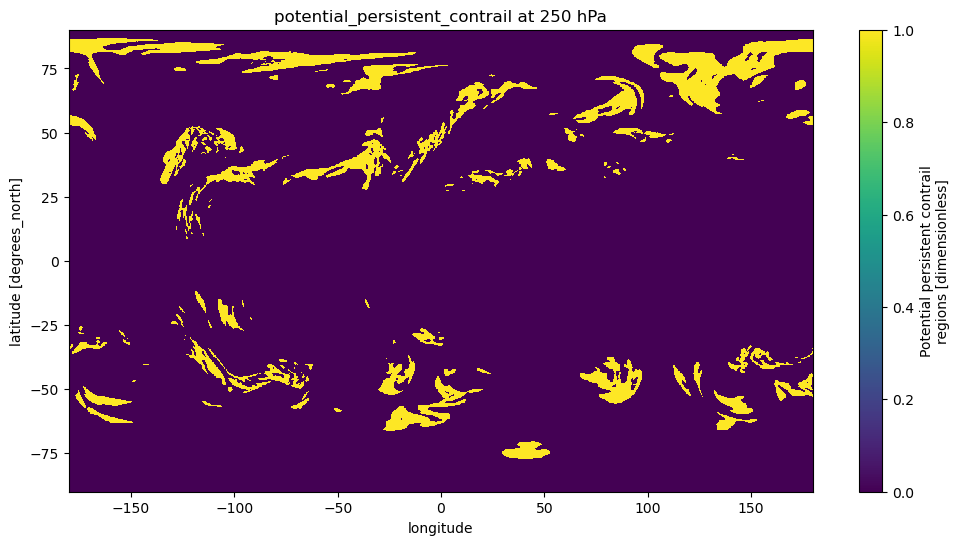

In [8]:
#var='air_temperature'
var='potential_persistent_contrail'
#var='T_contr'
result.data[var].sel(time=result.data.time[0], level=250).transpose().plot(figsize=(12, 6))
plt.title(var+' at 250 hPa')
plt.show()

### Plot

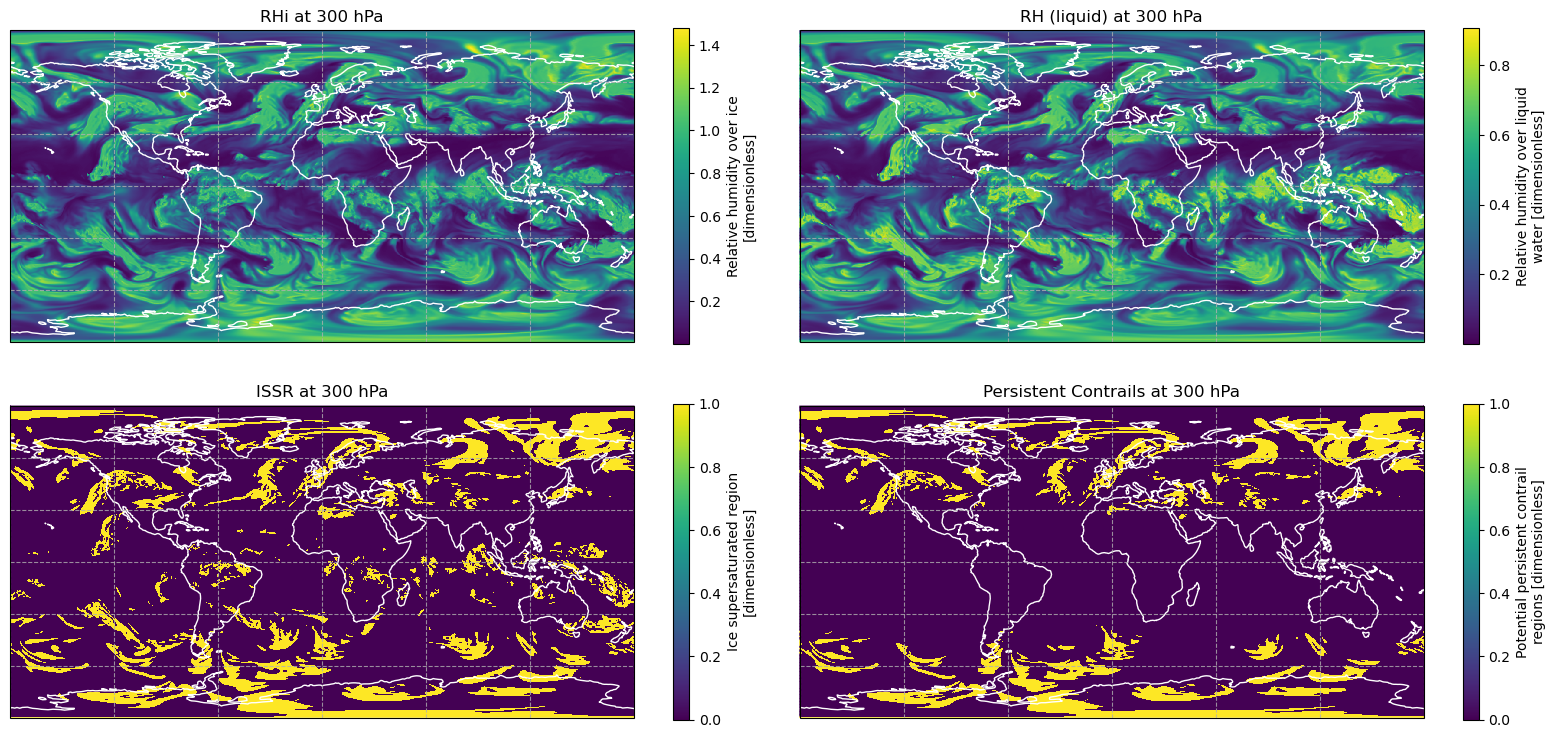

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(2, 2, figsize=(16, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

level = 300
time_idx = 1

fields = ['rhi', 'rh_liquid', 'issr', 'potential_persistent_contrail']
titles = ['RHi', 'RH (liquid)', 'ISSR', 'Persistent Contrails']

for ax, field, title in zip(axes.flat, fields, titles):
    data = result.data[field].sel(time=result.data.time[time_idx], level=level)
    data.transpose().plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'shrink': 0.8})
    ax.coastlines(color="white")
    ax.gridlines(alpha=0.8, linestyle='--')
    ax.set_title(f'{title} at {level} hPa')

plt.tight_layout()
plt.show()

In [ ]:
### Uses built in xarray plotting

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
#import cartopy.feature as cfeature

fig, axes = plt.subplots(2, 2, figsize=(20, 14), 
                         subplot_kw={'projection': ccrs.Robinson()})

level = 250
time_idx = 0

fields = ['rhi', 'rh_liquid', 'issr', 'potential_persistent_contrail']
titles = ['Relative Humidity over Ice', 'Relative Humidity over Liquid', 
          'Ice Supersaturated Regions', 'Potential Persistent Contrails']
cmaps = ['RdYlBu_r', 'RdYlBu_r', 'YlOrRd', 'RdYlGn']
vmins = [0, 0, 0, 0]
vmaxs = [1.5, 1, 1, 1]

for ax, field, title, cmap, vmin, vmax in zip(axes.flat, fields, titles, cmaps, vmins, vmaxs):
    data = result.data[field].sel(time=result.data.time[time_idx], level=level)
    
    # Use xarray's plot with transform
    data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        cbar_kwargs={'orientation': 'horizontal', 'pad': 0.05, 
                     'shrink': 0.8, 'label': title}
    )
    
    ax.coastlines(linewidth=0.8)
#    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', alpha=0.5)
    ax.gridlines(alpha=0.4, linestyle='--')
    ax.set_global()
    ax.set_title(title, fontsize=12, fontweight='bold')

fig.suptitle(f'UPCOM Model Output at {level} hPa\n{result.data.time[time_idx].values}', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
#Uses contourf (matplotlib)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
#import cartopy.feature as cfeature

fig, axes = plt.subplots(2, 2, figsize=(20, 14), 
                         subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

level = 250
time_idx = 0

fields = ['rhi', 'rh_liquid', 'issr', 'potential_persistent_contrail']
titles = ['Relative Humidity over Ice', 'Relative Humidity over Liquid', 
          'Ice Supersaturated Regions', 'Potential Persistent Contrails']
cmaps = ['RdYlBu_r', 'RdYlBu_r', 'YlOrRd', 'RdYlGn']
vmins = [0, 0, 0, 0]
vmaxs = [1.5, 1, 1, 1]

for ax, field, title, cmap, vmin, vmax in zip(axes.flat, fields, titles, cmaps, vmins, vmaxs):
    data = result.data[field].sel(time=result.data.time[time_idx], level=level)
    
    # Use contourf instead of pcolormesh
    im = ax.contourf(
        data.longitude, data.latitude, data.values,
        levels=20,  # Number of contour levels
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        extend='both'
    )
    
    ax.coastlines(linewidth=0.8, color='black')
#    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
#    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
#    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', alpha=0.5)
    ax.gridlines(alpha=0.4, linestyle='--')
    ax.set_global()
    
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', 
                       pad=0.05, shrink=0.8, aspect=30)
    cbar.set_label(title, fontsize=10)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

fig.suptitle(f'UPCOM Model Output at {level} hPa\n{result.data.time[time_idx].values}', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Diagnostic code
print("=== Diagnostics ===")
print(f"T_contr type: {type(result.data['T_contr'])}")
print(f"T_contr shape: {result.data['T_contr'].shape}")
print(f"T_contr dims: {result.data['T_contr'].dims}")
print(f"T_contr min/max: {result.data['T_contr'].min().values:.2f} / {result.data['T_contr'].max().values:.2f}")

print(f"\nAir temp min/max: {result.data['air_temperature'].min().values:.2f} / {result.data['air_temperature'].max().values:.2f}")
print(f"RHi min/max: {result.data['rhi'].min().values:.3f} / {result.data['rhi'].max().values:.3f}")
print(f"RH_liquid min/max: {result.data['rh_liquid'].min().values:.3f} / {result.data['rh_liquid'].max().values:.3f}")

print(f"\nG min/max: {result.data['G'].min().values:.6f} / {result.data['G'].max().values:.6f}")
print(f"G > 0.053: {(result.data['G'] > 0.053).sum().values} points")

print(f"\nCondition checks (count of True):")
print(f"  RHi > 1.0: {(result.data['rhi'] > 1.0).sum().values}")
print(f"  T < T_contr: {(result.data['air_temperature'] < result.data['T_contr']).sum().values}")
print(f"  RH_liquid > RH_contr: {(result.data['rh_liquid'] > result.data['RH_contr']).sum().values}")

print(f"\nPersistent contrails: {result.data['potential_persistent_contrail'].sum().values}")

# Check a specific point where RHi > 1
idx = np.where(result.data['rhi'].values > 1.0)
if len(idx[0]) > 0:
    i = idx[0][0]
    print(f"\n=== Example point with RHi > 1 ===")
    print(f"RHi: {result.data['rhi'].values.flat[i]:.3f}")
    print(f"T: {result.data['air_temperature'].values.flat[i]:.2f} K")
    print(f"T_contr: {result.data['T_contr'].values.flat[i]:.2f} K")
    print(f"RH_liquid: {result.data['rh_liquid'].values.flat[i]:.3f}")
    print(f"RH_contr: {result.data['RH_contr'].values.flat[i]:.3f}")
    print(f"G: {result.data['G'].values.flat[i]:.6f}")



In [ ]:
print(f"Air pressure min/max: {result.data['air_pressure'].min().values} / {result.data['air_pressure'].max().values}")
print(f"Air pressure units: {result.data['air_pressure'].attrs.get('units', 'not specified')}")
print(f"Air pressure shape: {result.data['air_pressure'].shape}")
print(f"Air pressure dims: {result.data['air_pressure'].dims}")

# Also check a single value
print(f"\nSample pressure value: {result.data['air_pressure'].values.flat[0]}")

In [ ]:
from pycontrails.physics import constants
print(f"c_pd = {constants.c_pd}")
print(f"epsilon = {constants.epsilon}")

In [ ]:
print(f"air_pressure dims: {met.data['air_pressure'].dims}")
print(f"air_pressure coords: {met.data['air_pressure'].coords}")
print(f"air_temperature dims: {met.data['air_temperature'].dims}")